In [29]:
# Get data from url
import pandas as pd

url = 'https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/heart.csv'
data = pd.read_csv(url)
data = data.drop(columns=['row.names'])
print(data)

     sbp  tobacco    ldl  adiposity  famhist  typea  obesity  alcohol  age  \
0    160    12.00   5.73      23.11  Present     49    25.30    97.20   52   
1    144     0.01   4.41      28.61   Absent     55    28.87     2.06   63   
2    118     0.08   3.48      32.28  Present     52    29.14     3.81   46   
3    170     7.50   6.41      38.03  Present     51    31.99    24.26   58   
4    134    13.60   3.50      27.78  Present     60    25.99    57.34   49   
..   ...      ...    ...        ...      ...    ...      ...      ...  ...   
457  214     0.40   5.98      31.72   Absent     64    28.45     0.00   58   
458  182     4.20   4.41      32.10   Absent     52    28.61    18.72   52   
459  108     3.00   1.59      15.23   Absent     40    20.09    26.64   55   
460  118     5.40  11.61      30.79   Absent     64    27.35    23.97   40   
461  132     0.00   4.82      33.41  Present     62    14.70     0.00   46   

     chd  
0      1  
1      1  
2      0  
3      1  
4      1

**Exploratory Data Analysis**

How much is the percentage of each class 0 or 1?

In [2]:
chd = data['chd']
chd_positive = chd.sum()
total = len(chd)
percentage = (chd_positive/total) * 100
print(f"Approximately {percentage:.2f}% of the population has coronary heart disease.")
print(f"Exact percentage: {percentage}.")

Approximately 34.63% of the population has coronary heart disease.
Exact percentage: 34.63203463203463.


How many missing values do we have?

In [3]:
missing_values = data.isnull().sum()
print(f"The missing value sums:\n{missing_values}")

The missing value sums:
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64


There are no missing values in any column.

How many categorical variables do you have in the features?

There is only one categorical feature variable although there are two categorical variables in the data: (1) family history and (2) the actual presence or absence of coronary heart disease. The rest of the variables are numerical. Thus, with respect to the features only, there is only one categorical variable.

Which features have the maximum correlation?

Variable     Correlation
chd          1.000000
age          0.372973
tobacco      0.299718
famhist      0.272373
ldl          0.263053
adiposity    0.254121
sbp          0.192354
typea        0.103156
obesity      0.100095
alcohol      0.062531
Name: chd, dtype: float64


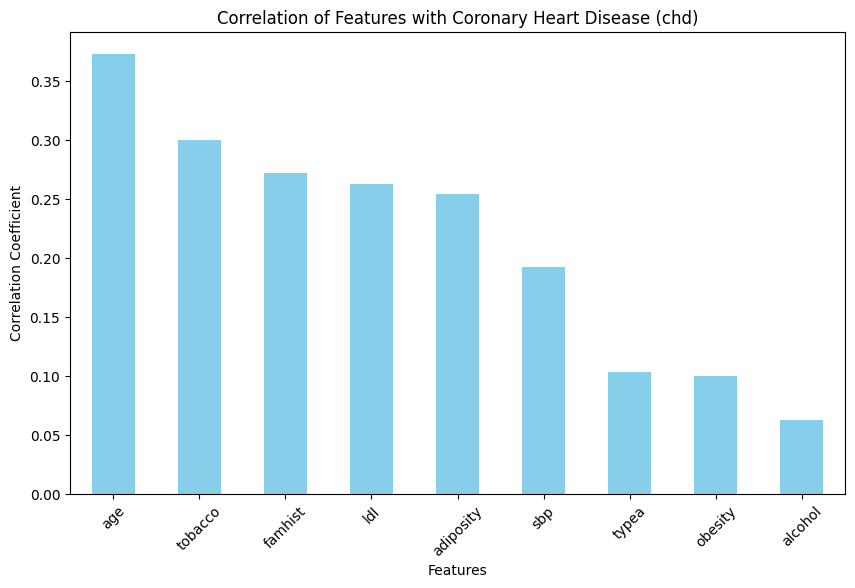

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_encoded = pd.get_dummies(data, columns=['famhist'], drop_first=True)
data_encoded.rename(columns={'famhist_Present': 'famhist'}, inplace=True)
correlation_matrix = data_encoded.corr()
chd_correlation = correlation_matrix['chd'].sort_values(ascending=False)

# Print correlation matrix
print("Variable     Correlation")
print(chd_correlation)

# Print bar graph
plt.figure(figsize=(10, 6))
chd_correlation.drop('chd').plot(kind='bar', color='skyblue')
plt.title('Correlation of Features with Coronary Heart Disease (chd)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45);
plt.show()

The relative correlation of each feature with coronary heart disease is presented above as a bar graph. The strongest correlation to coronary heart disease was found with the age feature. The weakest correlation was found with the alcohol feature.

**One-Hot Encoding and Standardization**

In [5]:
# Extract features to normalize
features_to_normalize = data_encoded.drop(columns=['chd', 'famhist'])

# Get mean and standard deviation
mean_values = features_to_normalize.mean()
std_values = features_to_normalize.std()
normalized_features = (features_to_normalize - mean_values) / std_values

# Concatenate normalized features with categorical features
data_normalized = pd.concat([normalized_features, data_encoded[['famhist', 'chd']]], axis=1)
print(data_normalized)

          sbp   tobacco       ldl  adiposity     typea   obesity   alcohol  \
0    1.057417  1.821099  0.477894  -0.295183 -0.418017 -0.176594  3.274189   
1    0.276789 -0.789382 -0.159507   0.411694  0.193134  0.670646 -0.612081   
2   -0.991731 -0.774141 -0.608585   0.883374 -0.112441  0.734723 -0.540597   
3    1.545310  0.841352  0.806252   1.622382 -0.214300  1.411091  0.294742   
4   -0.211103  2.169453 -0.598928   0.305020  0.702427 -0.012842  1.645991   
..        ...       ...       ...        ...       ...       ...       ...   
457  3.692037 -0.704470  0.598614   0.811401  1.109862  0.570971 -0.696228   
458  2.130781  0.122871 -0.159507   0.860240 -0.112441  0.608942  0.068445   
459 -1.479624 -0.138395 -1.521228  -1.307946 -1.334744 -1.413043  0.391960   
460 -0.991731  0.384137  3.317227   0.691875  1.109862  0.309916  0.282897   
461 -0.308682 -0.791559  0.038474   1.028605  0.906144 -2.692210 -0.696228   

          age  famhist  chd  
0    0.628654     True    1  
1  

**Hypothesis Model - The Sigmoid Function**

In [6]:
import numpy as np

def sigmoid(z):
  z = np.array(z)
  return 1 / (1 + np.exp(-z))

**The Cost Function - Binary Cross Entropy Loss Function**

In [7]:
import numpy as np

def cost(y_true, y_pred):
  epsilon = 1e-15
  y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Create upper and lower bounds
  loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
  return loss

**Batch Gradient Descent Iteration - The Update Function**

In [8]:
import numpy as np

def update_theta(theta_old, a, y_true, y_pred, x):
  theta_old = np.array(theta_old)
  gradient = np.mean((y_true - y_pred)[:, np.newaxis] * x, axis=0)
  theta_new = theta_old + a * gradient
  return theta_new

**Gradient Descent Function**

**Theta Initialization**

In [9]:
import numpy as np

# Remove chd
data_initialized = data_normalized.drop('chd', axis=1)

# Initialize theta weights
num_features = data_initialized.shape[1]
theta = np.random.rand(num_features + 1) # +1 for bias
print(theta)

[0.51669242 0.55418951 0.39705101 0.6117583  0.72952602 0.17988323
 0.26872596 0.53127168 0.47964903 0.07756375]


**Learning Curve**

In [10]:
import matplotlib.pyplot as plt

# Add bias column to data
X = np.c_[np.ones(data_initialized.shape[0]), data_initialized]
X = X.astype(np.float64)
y_true = data_normalized['chd'].values

In [11]:
def batch_gradient_descent(a, epochs):
  costs = []
  theta_old = theta
  for i in range(epochs):
    y_pred = sigmoid(np.dot(X, theta_old))
    cost_i = cost(y_true, y_pred)
    theta_old = update_theta(theta_old, a, y_true, y_pred, X)
    costs.append(cost_i)
  plt.figure(figsize=(10, 6))
  plt.plot(range(epochs), costs, label='Cost', color='blue')
  plt.title(f'Cost vs. Epochs of {a} Learning Rate')
  plt.xlabel('Epochs')
  plt.ylabel('Cost')
  plt.legend()
  plt.grid()
  plt.show()
  return theta_old

For learning rate of 0.001 and 500 epochs.

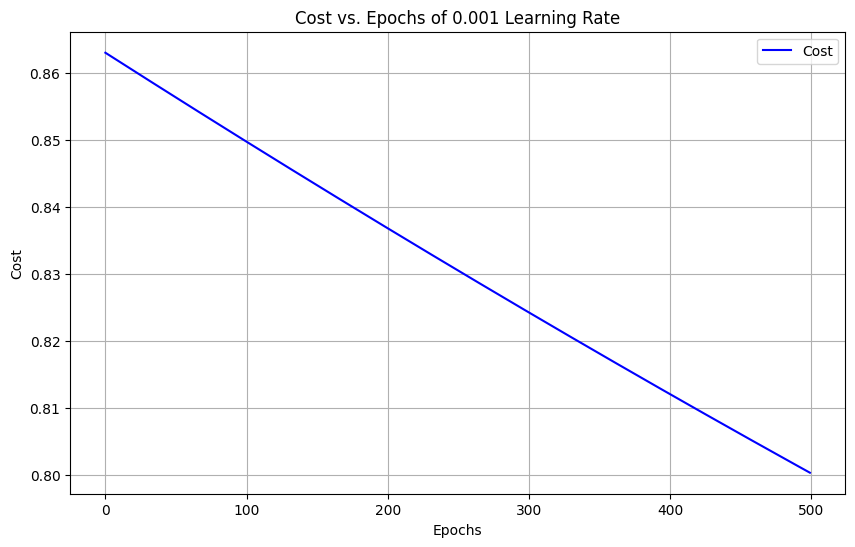

In [12]:
a = 0.001
epochs = 500
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.001 and 1000 epochs.

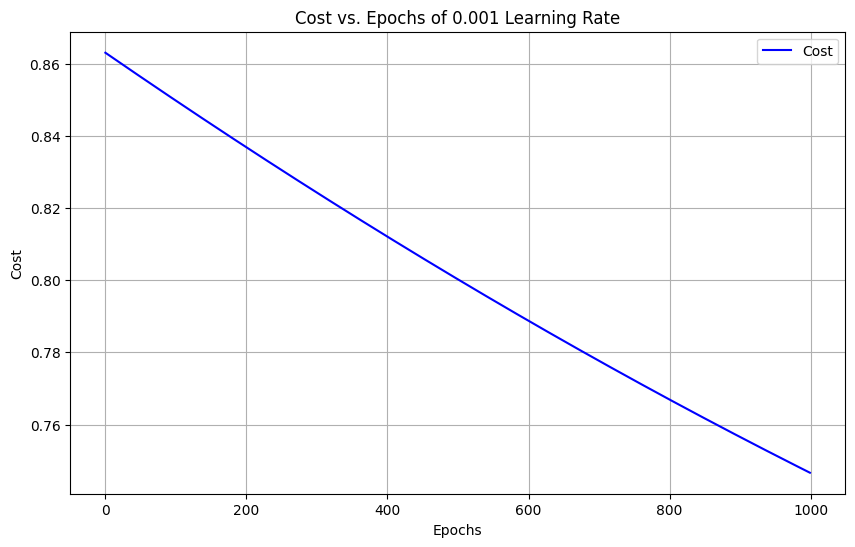

In [13]:
a = 0.001
epochs = 1000
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.001 and 10 000 epochs.

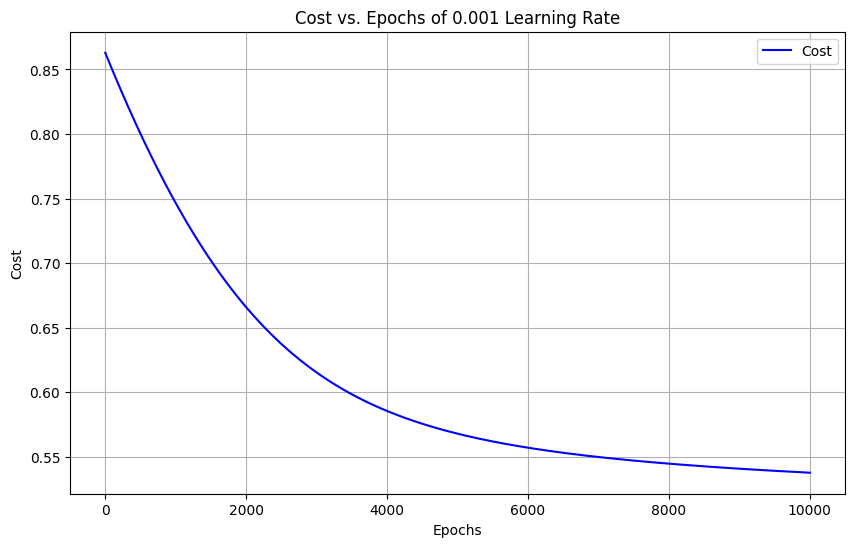

In [14]:
a = 0.001
epochs = 10000
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.001 and 50 000 epochs. This was not required!

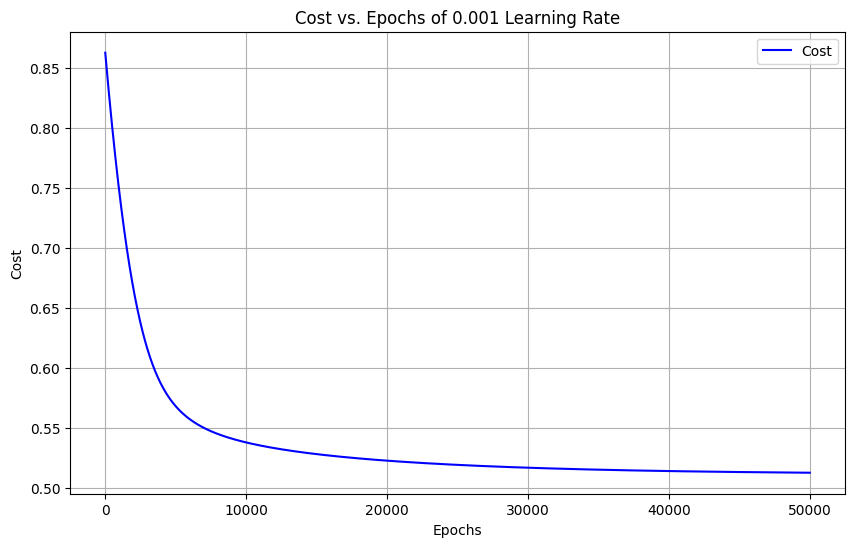

In [15]:
a = 0.001
epochs = 50000
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 500 epochs.

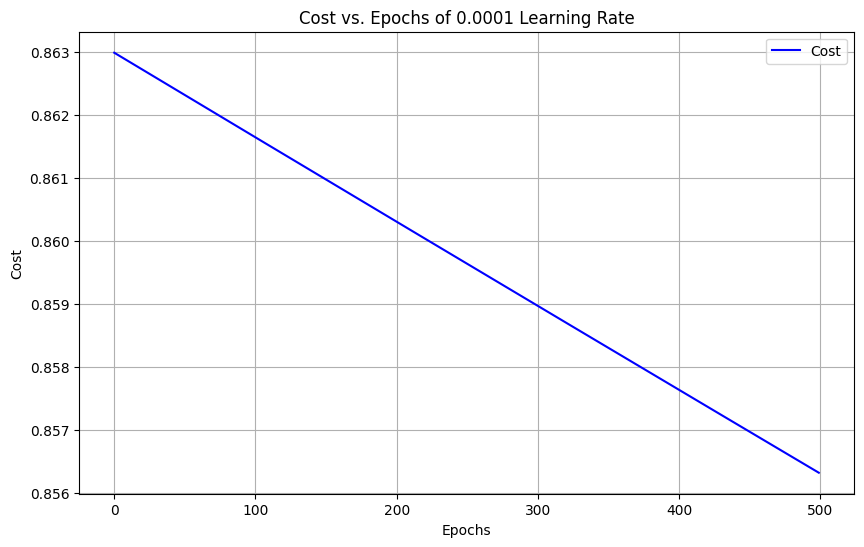

In [16]:
a = 0.0001
epochs = 500
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 1000 epochs.

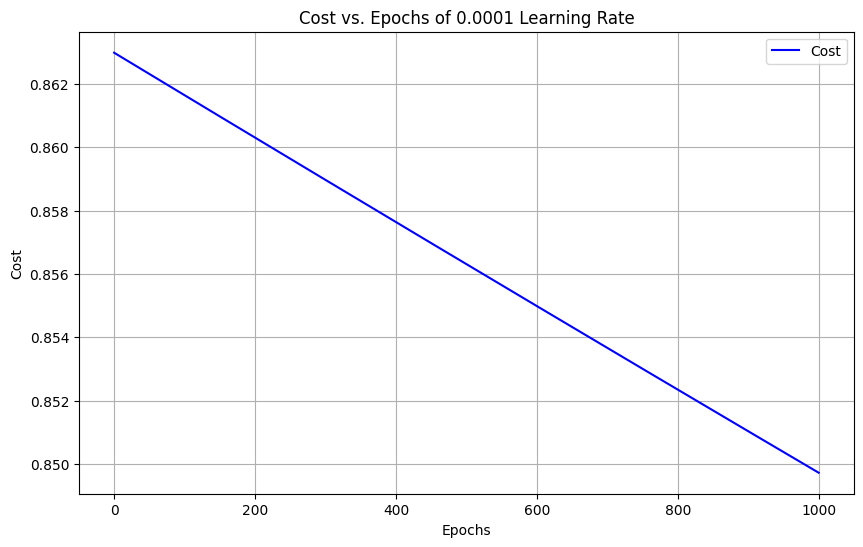

In [17]:
a = 0.0001
epochs = 1000
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 10 000 epochs.

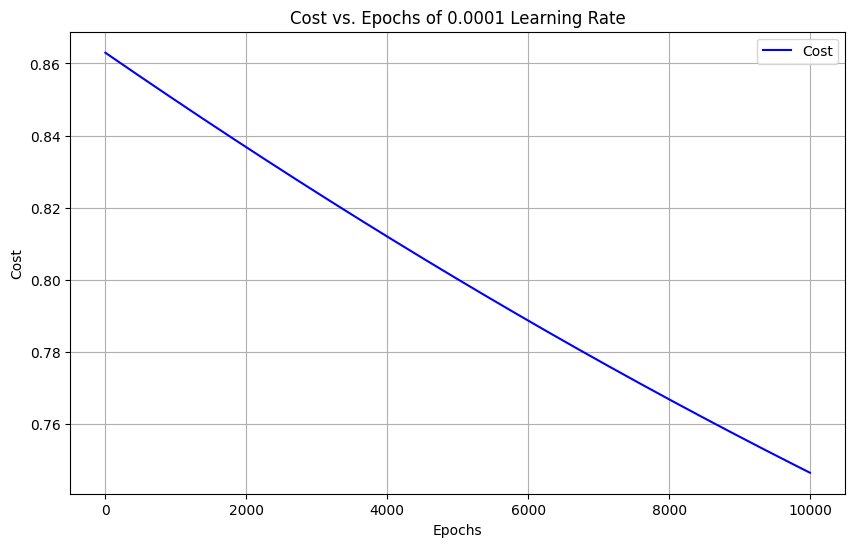

In [18]:
a = 0.0001
epochs = 10000
theta_old = batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 100 000 epochs. Again, this was not required.

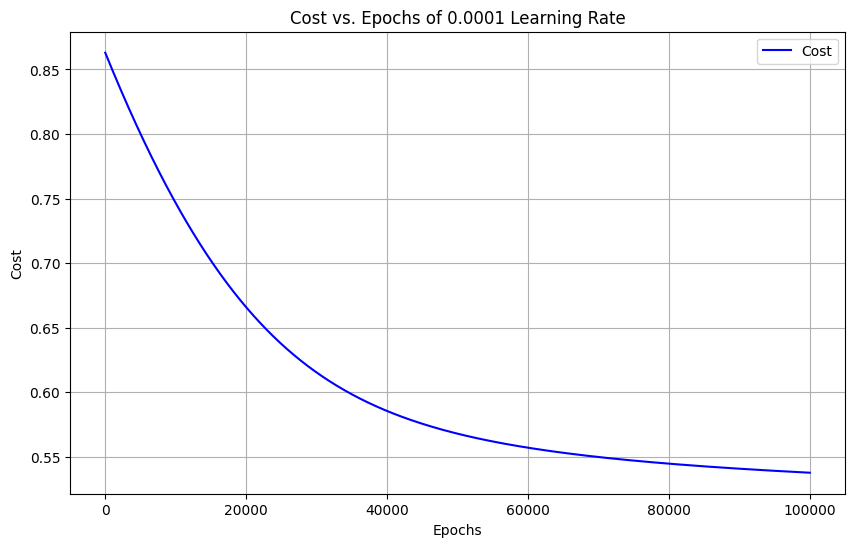

In [19]:
a = 0.0001
epochs = 100000
theta_old = batch_gradient_descent(a, epochs)

After the six trials, a learning rate of 0.001 required 10 000 epochs for the curve's slope to begin decreasing slowly. For the smaller learning rate of 0.0001, approximately 60 to 70 thousand epochs were needed to produce the same effect. At these points, the slope of the graph decreased to where successive updates to the predicted y and theta values did not diminish the cost as significantly as eariler.

**Mini-Batch Gradient Descent**

In [20]:
batch_size = 50

In [21]:
def mini_batch_gradient_descent(a, epochs):
  costs = []
  theta_old = theta
  for i in range(epochs):
    for j in range(0, X.shape[0], batch_size):
      X_batch = X[j:j + batch_size]
      y_true_batch = y_true[j:j + batch_size]
      y_pred_batch = sigmoid(np.dot(X_batch, theta_old))
      theta_old = update_theta(theta_old, a, y_true_batch, y_pred_batch, X_batch)
    y_pred = sigmoid(np.dot(X, theta_old))
    cost_i = cost(y_true, y_pred)
    theta_old = update_theta(theta_old, a, y_true, y_pred, X)
    costs.append(cost_i)
  plt.figure(figsize=(10, 6))
  plt.plot(range(epochs), costs, label='Cost', color='blue')
  plt.title(f'Cost vs. Epochs of {a} Learning Rate')
  plt.xlabel('Epochs')
  plt.ylabel('Cost')
  plt.legend()
  plt.grid()
  plt.show()
  return theta_old

For learning rate of 0.001 and 500 epochs.

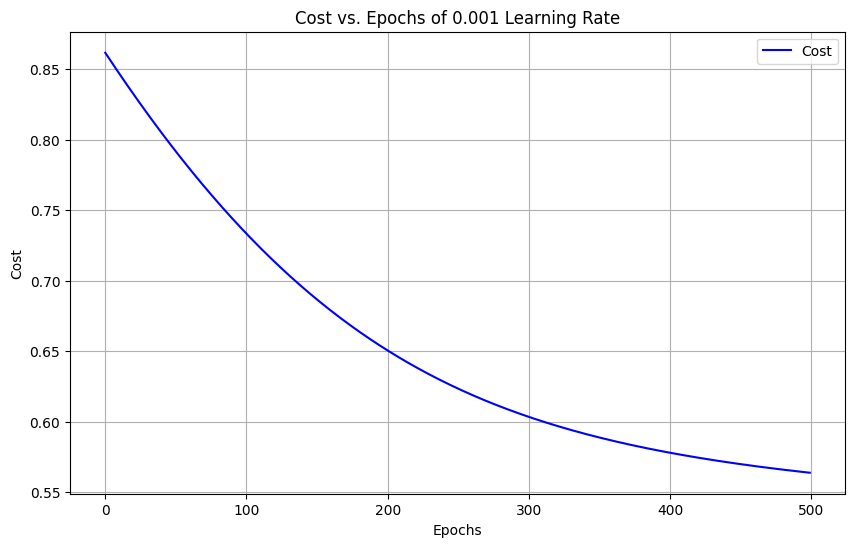

In [22]:
a = 0.001
epochs = 500
theta_old = mini_batch_gradient_descent(a, epochs)

For learning rate of 0.001 and 1000 epochs.

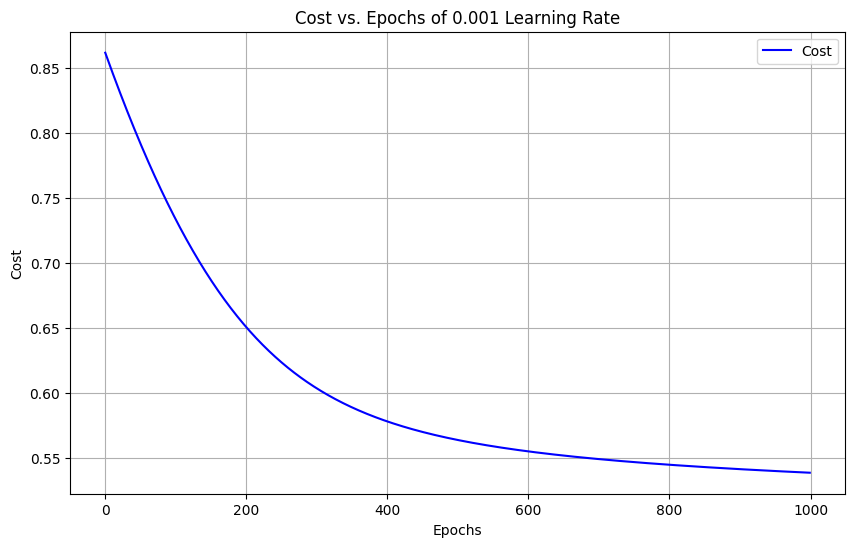

In [23]:
a = 0.001
epochs = 1000
theta_old = mini_batch_gradient_descent(a, epochs)

For learning rate of 0.001 and 10 000 epochs.

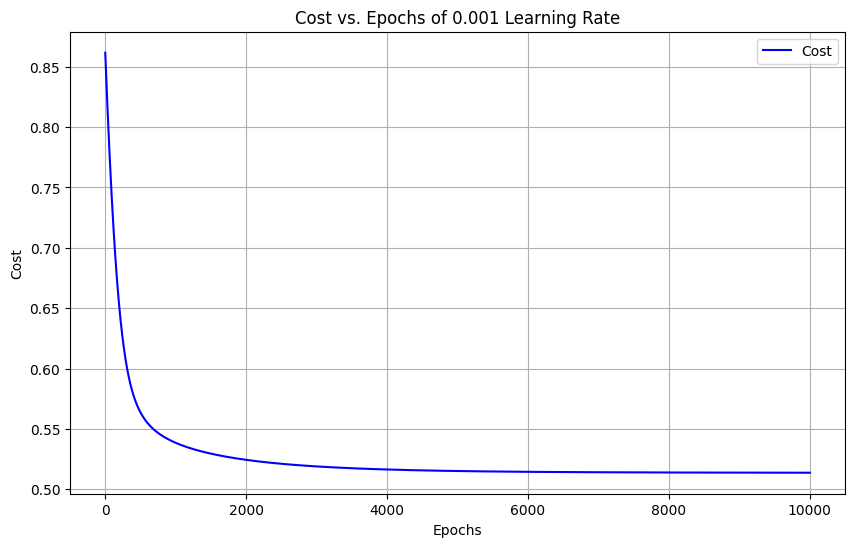

In [24]:
a = 0.001
epochs = 10000
theta_old = mini_batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 500 epochs.

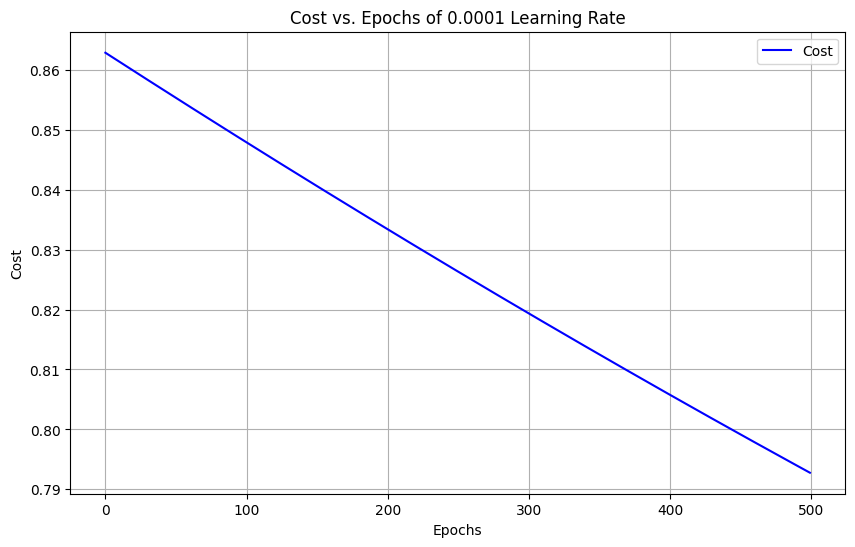

In [25]:
a = 0.0001
epochs = 500
theta_old = mini_batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 1000 epochs.

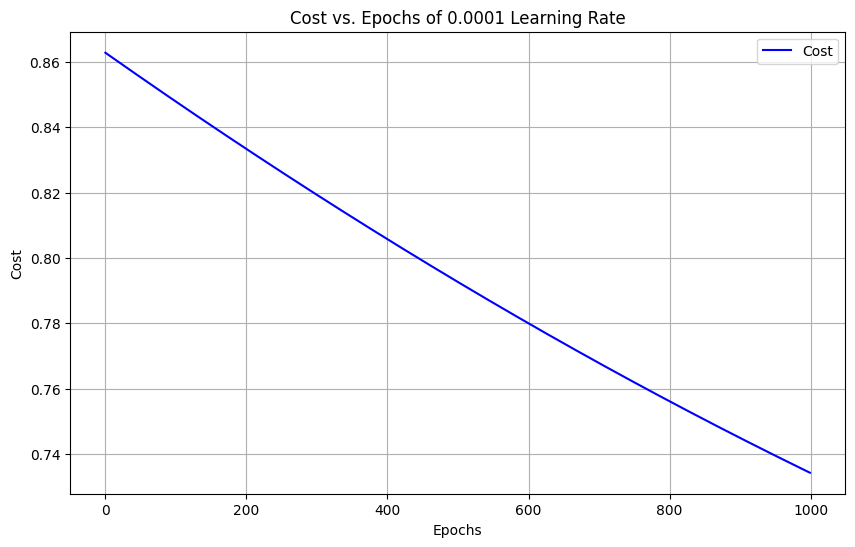

In [26]:
a = 0.0001
epochs = 1000
theta_old = mini_batch_gradient_descent(a, epochs)

For learning rate of 0.0001 and 10 000 epochs.

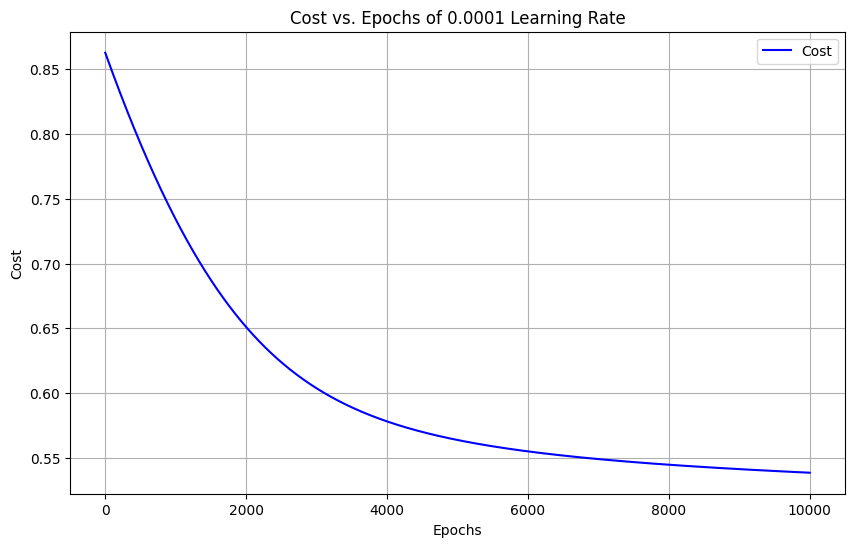

In [27]:
a = 0.0001
epochs = 10000
theta_old = mini_batch_gradient_descent(a, epochs)

The mini-batch gradient descent trials outperformed the batch gradient descent. Generally, 600 epochs retrieved the same point within the mini-batch gradient descent trials for the learning rate of 0.001. And 3000 epochs did the same with the learning rate of 0.0001. This was a significant reduction in epochs required to achieve stability in cost reductions with respect to increasing epochs.

**Implemented Library Comparison**

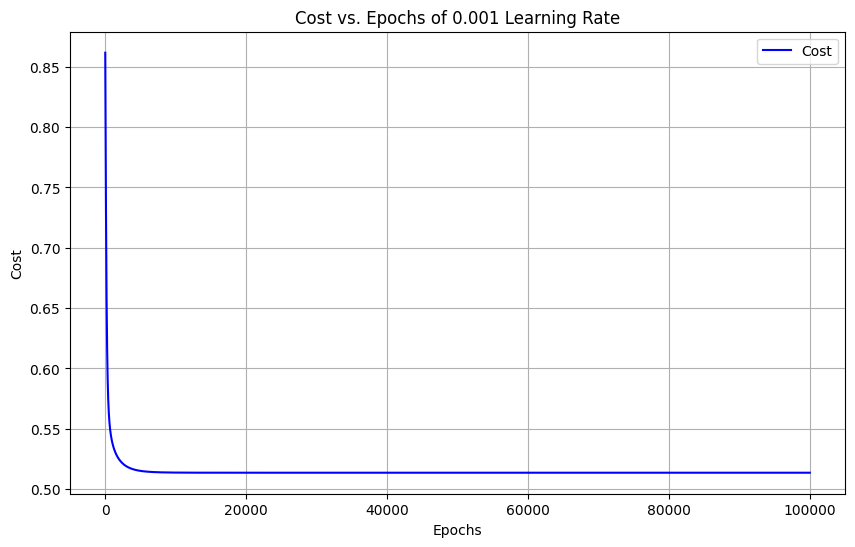

Pearson coefficient --> 0.9846368426553498
 1 implies a perfect positive correlation
 0 implies no correlation
-1 implies a perfect negative (inverse) correlation


In [28]:
from sklearn.linear_model import LogisticRegression

a = 0.001 # learning rate
epochs = 100000 # number of epochs
# update theta to compare with sklearns LogisticRegression
# generated theta values BELOW
# theta_old = batch_gradient_descent(a, epochs)
theta_old = mini_batch_gradient_descent(a, epochs)

model = LogisticRegression(fit_intercept=False, solver='lbfgs')
model.fit(X, y_true)
theta_sklearn = np.hstack([model.intercept_, model.coef_.flatten()])
theta_sklearn = model.coef_.flatten()

r = np.corrcoef(theta_sklearn, theta_old)[0, 1]
print("Pearson coefficient -->", r)
print(" 1 implies a perfect positive correlation")
print(" 0 implies no correlation")
print("-1 implies a perfect negative (inverse) correlation")

Checking for correlation yielded positive results. The Pearson correlation coefficient was found to be 0.7 and above for all learning rates (after 10 000 epochs) in the mini-batch gradient descent trials. For mini-batch gradient descenet with a learning rate of 0.001 and 10 000 epochs, the coefficient was found to be 0.98. This indicates an extremely precise positive correlation between the theta values generated through this notebook and those generated by sklearn. (Obviously, this will depend on the initialization of theta values as well.) The Pearson coefficient was also above 0.8 in the batch gradient descent with the higher learning rate of 0.001 for 10 000 epochs. It was not correlated with respect to the learning rate of 0.0001 and 10 000 epochs in batch gradient descent as the 10 000 epochs, as previously discussed, was not enough to render this trial very accurate.

Additionally, when larger numbers of epochs were used (greater than 10 000 epochs), the theta values, as expected, depicted an even greater positive correlation with those values projected by sklearn.